In [32]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import panel_utils
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import f
from panel_utils import (
    detect_outlier_regions_iqr,
    friedman_seasonality_test,
    run_panel_unit_root_tests,
    seasonal_adjust_panel_series,
    run_friedman_seasonality_tests,
    ModelResultsAggregator,
    run_panel_regressions,
    run_spec_tests,
    run_panel_model_diagnostics,
    run_panel_regressions_trend
)

Обработка данных

In [33]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
pickle_filename = 'region_cluster_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_region_cluster = pickle.load(f)
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
pickle_filename = 'ent_conf_index.pkl'
with open(pickle_filename, 'rb') as f:
    df_ent_conf = pickle.load(f)

In [34]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [4]:
df_RF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Num_reg                     81 non-null     int64         
 1   Region                      81 non-null     object        
 2   Date                        81 non-null     datetime64[ns]
 3   CAR_Indicator               81 non-null     float64       
 4   D_Progr_mort                81 non-null     float64       
 5   ROISFIX                     81 non-null     float64       
 6   exc_rate                    81 non-null     float64       
 7   exc_rate_diff               81 non-null     float64       
 8   Bonds_Rate_Correct_5Y       81 non-null     float64       
 9   Inflation_Expectations      81 non-null     float64       
 10  Nominal_Percent_Rate        81 non-null     float64       
 11  Ent_conf_ind_mining         81 non-null     int64         
 

In [5]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6885 entries, 0 to 6884
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Num_reg                    6885 non-null   int64         
 1   Region                     6885 non-null   object        
 2   Date                       6885 non-null   datetime64[ns]
 3   D_top5_rozn                6885 non-null   float64       
 4   Cred_nagr                  6715 non-null   float64       
 5   Zakred                     6715 non-null   float64       
 6   Zadolg_Fl                  6885 non-null   float64       
 7   Zadolg_Mort                6885 non-null   float64       
 8   Zadolg_ConsCred            6885 non-null   float64       
 9   Zadolg_Fl_mom              6885 non-null   float64       
 10  Zadolg_Mort_mom            6885 non-null   float64       
 11  Zadolg_ConsCred_mom        6885 non-null   float64       
 12  Cred_s

In [6]:
df_region_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Region     85 non-null     object
 1   Cluster_1  85 non-null     int32 
 2   Cluster_2  85 non-null     int32 
dtypes: int32(2), object(1)
memory usage: 1.5+ KB


In [7]:
df_shocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 1 to 80
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       80 non-null     datetime64[ns]
 1   Mon_Shock  80 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 KB


In [8]:
df_ent_conf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                81 non-null     datetime64[ns]
 1   Ent_conf_ind_total  81 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.4 KB


In [9]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')
df_reg = df_reg.merge(df_ent_conf[['Date', 'Ent_conf_ind_total']], on='Date', how='left')
df_rf_extra = df_RF[['Date','REER', 'MIACR', 'Covid_dum', 'Sank_dum', 'ROISFIX', 'MaP_Tight_Announcement', 
                     'MaP_Ease_Announcement', 'MaP_Tight_Fact', 'MaP_Ease_Fact',
                     'Oil_p']].copy()
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

map_cols = [
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact'
]
df_reg[map_cols] = df_reg[map_cols].fillna(0)

#Расчетные показатели
df_reg['Oil_p_share_mining'] = df_reg['Oil_p'] * df_reg['Share_mining']
df_reg['Share_Mort_Progr_new'] = df_reg['New_Loans_Progr'] / df_reg['New_Loans_Mort']

# Создаем лаги
df_reg['D_top5_rozn_lag1'] = df_reg.groupby('Region')['D_top5_rozn'].shift(1)
df_reg['CPI_lag1'] = df_reg.groupby('Region')['CPI'].shift(1)
df_reg['Def_Zadolg_Fl_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Fl'].shift(1)
df_reg['Def_Zadolg_Mort_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Mort'].shift(1)
df_reg['Def_Zadolg_ConsCred_lag1'] = df_reg.groupby('Region')['Def_Zadolg_ConsCred'].shift(1)
df_reg['Cap_to_assets_lag1'] = df_reg.groupby('Region')['Cap_to_assets'].shift(1)
        
# Разделим Mon_Shock на позитивный и негативный
df_reg['Mon_Shock_neg'] = df_reg['Mon_Shock'].where(df_reg['Mon_Shock'] < 0, 0)
df_reg['Mon_Shock_pos'] = df_reg['Mon_Shock'].where(df_reg['Mon_Shock'] > 0, 0)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    #Блок 1 - Зависимые переменные + лаги
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum',
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()
df_reg_analys = df_reg_analys[df_reg_analys['Region'] != 'Москва']
cols_for_drop = [c for c in df_reg_analys.columns]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

In [10]:
df_reg_analys.head()

,Region,Date,New_Loans_Fl,New_Loans_Mort,New_Loans_ConsCred,MaP_Tight_Announcement,MaP_Ease_Announcement,MaP_Tight_Fact,MaP_Ease_Fact,D_top5_rozn_lag1,...,Oil_p_share_mining,REER,Mon_Shock_pos,Mon_Shock_neg,ROISFIX,MIACR,Cluster_1,Cluster_2,Covid_dum,Sank_dum
1,Белгородская область,2019-03-01,8.598020e+06,1.581850e+06,7.016170e+06,0,0,0,0,0.720458,...,12.664594,1.2,0.320202,0.000000,7.611500,7.68,0,0,0,0
2,Белгородская область,2019-04-01,9.938011e+06,1.535489e+06,8.402522e+06,0,0,1,0,0.721863,...,13.766905,1.2,0.152042,0.000000,7.630000,7.75,0,0,0,0
3,Белгородская область,2019-05-01,1.042482e+07,1.654725e+06,8.770090e+06,0,0,0,0,0.724760,...,13.790537,0.5,0.197636,0.000000,7.635556,7.72,0,0,0,0
4,Белгородская область,2019-06-01,9.595191e+06,1.375143e+06,8.220047e+06,0,0,0,0,0.724868,...,11.890560,0.3,0.000000,-0.148779,7.524737,7.58,0,0,0,0
5,Белгородская область,2019-07-01,9.632884e+06,1.541998e+06,8.090886e+06,1,0,0,0,0.724590,...,12.161280,1.5,0.000000,-0.099468,7.341304,7.32,0,0,0,0


In [11]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6800 entries, 1 to 6884
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Region                    6800 non-null   object        
 1   Date                      6800 non-null   datetime64[ns]
 2   New_Loans_Fl              6800 non-null   float64       
 3   New_Loans_Mort            6800 non-null   float64       
 4   New_Loans_ConsCred        6800 non-null   float64       
 5   MaP_Tight_Announcement    6800 non-null   int64         
 6   MaP_Ease_Announcement     6800 non-null   int64         
 7   MaP_Tight_Fact            6800 non-null   int64         
 8   MaP_Ease_Fact             6800 non-null   int64         
 9   D_top5_rozn_lag1          6800 non-null   float64       
 10  Fin_Dostup                6800 non-null   float64       
 11  Def_Zadolg_Fl_lag1        6800 non-null   float64       
 12  Def_Zadolg_Mort_lag1     

IQR очистка

In [12]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'D_top5_rozn_lag1',
    'Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    'CPI_lag1',
    'Oil_p_share_mining',
]
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     80   0.0%             1    1.2%                                  KEEP
                                    Брянская область     80   0.0%             0    0.0%                                  KEEP
                                Владимирская область     80   0.0%             0    0.0%                                  KEEP
                                 Воронежская область     80   0.0%             0    0.0%                                  KEEP
                                  Ивановская область     80   0.0%             0    0.0%                                  KEEP
                                    Тверская область     80   0.0%             0    0.0%                                  KEEP
                                   Калужская область

Описательные статистики и корреляционная матрица для базовых переменных

In [13]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
descriptive_df = df_reg_analys[[
    #Блок 1 - Зависимые переменные 
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    #Блок 2 - Переменные интереса 
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
    
]]
desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                               Среднее       Медиана     ст. откл.  \
New_Loans_Fl              2.139740e+07  1.170118e+07  3.299473e+07   
New_Loans_Mort            5.190889e+06  2.670723e+06  8.629242e+06   
New_Loans_ConsCred        1.620651e+07  8.830942e+06  2.500201e+07   
MaP_Tight_Announcement    2.120000e-01  0.000000e+00  4.090000e-01   
MaP_Ease_Announcement    -1.380000e-01  0.000000e+00  3.440000e-01   
MaP_Tight_Fact            2.120000e-01  0.000000e+00  4.090000e-01   
MaP_Ease_Fact             1.380000e-01  0.000000e+00  3.440000e-01   
D_top5_rozn_lag1          7.850000e-01  7.810000e-01  6.400000e-02   
Fin_Dostup                1.918800e+01  1.861500e+01  6.015000e+00   
Def_Zadolg_Fl_lag1        4.231000e+00  4.152000e+00  1.137000e+00   
Def_Zadolg_Mort_lag1      6.220000e-01  4.800000e-01  5.180000e-01   
Def_Zadolg_ConsCred_lag1  7.450000e+00  7.419000e+00  1.573000e+00   
Cap_to_assets_lag1        1.362100e+0

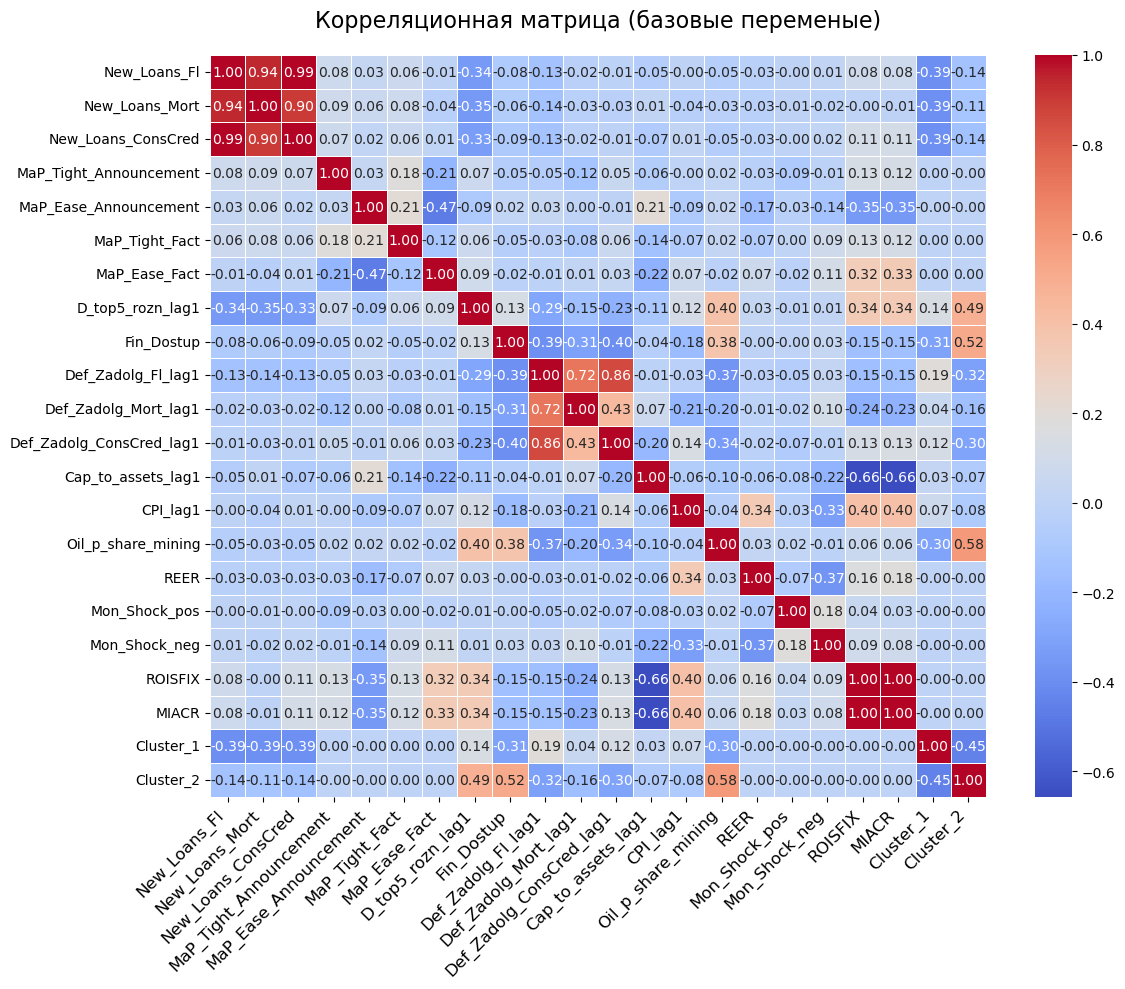

In [14]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - БАЗОВЫЕ ПЕРЕМЕННЫЕ
###############################
descriptive_df = df_reg_analys[[
    #Блок 1 - Зависимые переменные 
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    #Блок 2 - Переменные интереса 
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2' 
]]
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (базовые переменые)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

Тест Фридмана на сезонность

In [15]:
fed_cols_for_friedman = [
    'Date',
    'Bonds_Rate_Correct_5Y',
    'REER',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'ROISFIX',
    'Oil_p'
]

df_analysis = df_RF[fed_cols_for_friedman].copy()

df_analysis = df_analysis.merge(
    df_ent_conf[['Date', 'Ent_conf_ind_total']],
    on='Date',
    how='left'
)
friedman_summary = panel_utils.run_friedman_seasonality_tests(
    df_analysis,
    date_col='Date'
)


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
             Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Bonds_Rate_Correct_5Y     3.800000 0.975406            False        5        12
                 REER    19.892632 0.046835             True        5        12
                MIACR     3.774737 0.976049            False        5        12
            Covid_dum     7.615385 0.747286            False        5        12
             Sank_dum    11.000000 0.443263            False        5        12
              ROISFIX     4.456963 0.954598            False        5        12
                Oil_p     4.815385 0.939776            False        5        12
   Ent_conf_ind_total    13.030769 0.291319            False        5        12


Преобразоание данных

In [16]:
###############################
# Переход к первым разностям и логарифмам
###############################
df_reg = df_reg_analys.copy()

# ============ ЛОГАРИФМИРОВАНИЕ ============

loan_vars = ['New_Loans_Fl', 'New_Loans_Mort', 'New_Loans_ConsCred', 'Fin_Dostup']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])
        
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ  ============

exclude_cols = ['Region', 'Date']

# Разности для логарифмов 
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# Создаем лаги
df_reg['ln_New_Loans_Fl_lag1'] = df_reg.groupby('Region')['ln_New_Loans_Fl'].shift(1)
df_reg['ln_New_Loans_Mort_lag1'] = df_reg.groupby('Region')['ln_New_Loans_Mort'].shift(1)
df_reg['ln_New_Loans_ConsCred_lag1'] = df_reg.groupby('Region')['ln_New_Loans_ConsCred'].shift(1)
df_reg['MaP_Tight_Announcement_lag1'] = df_reg.groupby('Region')['MaP_Tight_Announcement'].shift(1)
df_reg['MaP_Ease_Announcement_lag1'] = df_reg.groupby('Region')['MaP_Ease_Announcement'].shift(1)
df_reg['MaP_Tight_Fact_lag1'] = df_reg.groupby('Region')['MaP_Tight_Fact'].shift(1)
df_reg['MaP_Ease_Fact_lag1'] = df_reg.groupby('Region')['MaP_Ease_Fact'].shift(1)
df_reg['Mon_Shock_pos_lag1'] = df_reg.groupby('Region')['Mon_Shock_pos'].shift(1)
df_reg['Mon_Shock_neg_lag1'] = df_reg.groupby('Region')['Mon_Shock_neg'].shift(1)
df_reg['ROISFIX_lag1'] = df_reg.groupby('Region')['ROISFIX'].shift(1)
df_reg['MIACR_lag1'] = df_reg.groupby('Region')['MIACR'].shift(1)

# Создаем взаимодействия
map_vars = [
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
]

z_vars = [
    'D_top5_rozn_lag1',
    'Cap_to_assets_lag1',
    'Cluster_1',
    'Cluster_2'
]
for m in map_vars:
    for z in z_vars:
        col_name = f"{m}_{z}"
        df_reg[col_name] = df_reg[m] * df_reg[z]

exog_vars = [
    #Блок 1 - Зависимые переменные + лаги
    'ln_New_Loans_Fl',
    'ln_New_Loans_Mort',
    'ln_New_Loans_ConsCred',
    'ln_New_Loans_Fl_lag1',
    'ln_New_Loans_Mort_lag1',
    'ln_New_Loans_ConsCred_lag1',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    'MaP_Tight_Announcement_lag1',
    'MaP_Ease_Announcement_lag1',
    'MaP_Tight_Fact_lag1',
    'MaP_Ease_Fact_lag1',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    'Mon_Shock_pos_lag1',
    'Mon_Shock_neg_lag1',
    'ROISFIX_lag1',
    'MIACR_lag1',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum',
    #Блок 8 - взаимодействия
    'MaP_Tight_Announcement_D_top5_rozn_lag1',
    'MaP_Tight_Fact_D_top5_rozn_lag1',
    'MaP_Ease_Announcement_D_top5_rozn_lag1',
    'MaP_Ease_Fact_D_top5_rozn_lag1',
    'MaP_Tight_Announcement_Cap_to_assets_lag1',
    'MaP_Tight_Fact_Cap_to_assets_lag1',
    'MaP_Ease_Announcement_Cap_to_assets_lag1',
    'MaP_Ease_Fact_Cap_to_assets_lag1',
    'MaP_Tight_Announcement_Cluster_1',
    'MaP_Tight_Fact_Cluster_1',
    'MaP_Ease_Announcement_Cluster_1',
    'MaP_Ease_Fact_Cluster_1',
    'MaP_Tight_Announcement_Cluster_2',
    'MaP_Tight_Fact_Cluster_2',
    'MaP_Ease_Announcement_Cluster_2',
    'MaP_Ease_Fact_Cluster_2' 
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
df_exog = df_exog.dropna()

In [17]:
df_exog.head()

,Region,Date,ln_New_Loans_Fl,ln_New_Loans_Mort,ln_New_Loans_ConsCred,ln_New_Loans_Fl_lag1,ln_New_Loans_Mort_lag1,ln_New_Loans_ConsCred_lag1,MaP_Tight_Announcement,MaP_Ease_Announcement,...,MaP_Ease_Announcement_Cap_to_assets_lag1,MaP_Ease_Fact_Cap_to_assets_lag1,MaP_Tight_Announcement_Cluster_1,MaP_Tight_Fact_Cluster_1,MaP_Ease_Announcement_Cluster_1,MaP_Ease_Fact_Cluster_1,MaP_Tight_Announcement_Cluster_2,MaP_Tight_Fact_Cluster_2,MaP_Ease_Announcement_Cluster_2,MaP_Ease_Fact_Cluster_2
2,Белгородская область,2019-04-01,16.111877,14.244360,15.944042,15.967042,14.274105,15.763728,0,0,...,0.0,0.0,0,0,0,0,0,0,0,0
3,Белгородская область,2019-05-01,16.159700,14.319145,15.986858,16.111877,14.244360,15.944042,0,0,...,0.0,0.0,0,0,0,0,0,0,0,0
4,Белгородская область,2019-06-01,16.076773,14.134069,15.922087,16.159700,14.319145,15.986858,0,0,...,0.0,0.0,0,0,0,0,0,0,0,0
5,Белгородская область,2019-07-01,16.080693,14.248590,15.906249,16.076773,14.134069,15.922087,1,0,...,0.0,0.0,0,0,0,0,0,0,0,0
6,Белгородская область,2019-08-01,16.147100,14.260453,15.982722,16.080693,14.248590,15.906249,0,0,...,0.0,0.0,0,0,0,0,0,0,0,0


In [18]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6399 entries, 2 to 6884
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Region                                     6399 non-null   object        
 1   Date                                       6399 non-null   datetime64[ns]
 2   ln_New_Loans_Fl                            6399 non-null   float64       
 3   ln_New_Loans_Mort                          6399 non-null   float64       
 4   ln_New_Loans_ConsCred                      6399 non-null   float64       
 5   ln_New_Loans_Fl_lag1                       6399 non-null   float64       
 6   ln_New_Loans_Mort_lag1                     6399 non-null   float64       
 7   ln_New_Loans_ConsCred_lag1                 6399 non-null   float64       
 8   MaP_Tight_Announcement                     6399 non-null   int64         
 9   MaP_Ease_Announcement   

In [19]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
descriptive_df = df_exog[[
    #Блок 1 - Зависимые переменные + лаги
    'ln_New_Loans_Fl',
    'ln_New_Loans_Mort',
    'ln_New_Loans_ConsCred',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
]]
desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
                          Среднее  Медиана  ст. откл.    Мин.     Макс.
ln_New_Loans_Fl            16.300   16.279      1.066  12.459    19.981
ln_New_Loans_Mort          14.794   14.805      1.160  10.000    18.529
ln_New_Loans_ConsCred      16.030   15.999      1.058  12.196    19.896
MaP_Tight_Announcement      0.215    0.000      0.411   0.000     1.000
MaP_Ease_Announcement      -0.139    0.000      0.346  -1.000     0.000
MaP_Tight_Fact              0.215    0.000      0.411   0.000     1.000
MaP_Ease_Fact               0.139    0.000      0.346   0.000     1.000
D_top5_rozn_lag1            0.785    0.782      0.064   0.614     0.948
ln_Fin_Dostup               2.899    2.922      0.353   1.089     3.869
Def_Zadolg_Fl_lag1          4.220    4.146      1.130   1.407    13.502
Def_Zadolg_Mort_lag1        0.618    0.476      0.516   0.043     4.649
Def_Zadolg_ConsCred_lag1    7.441    7.414      1.569   2.154    20.959
Cap_to_assets_lag

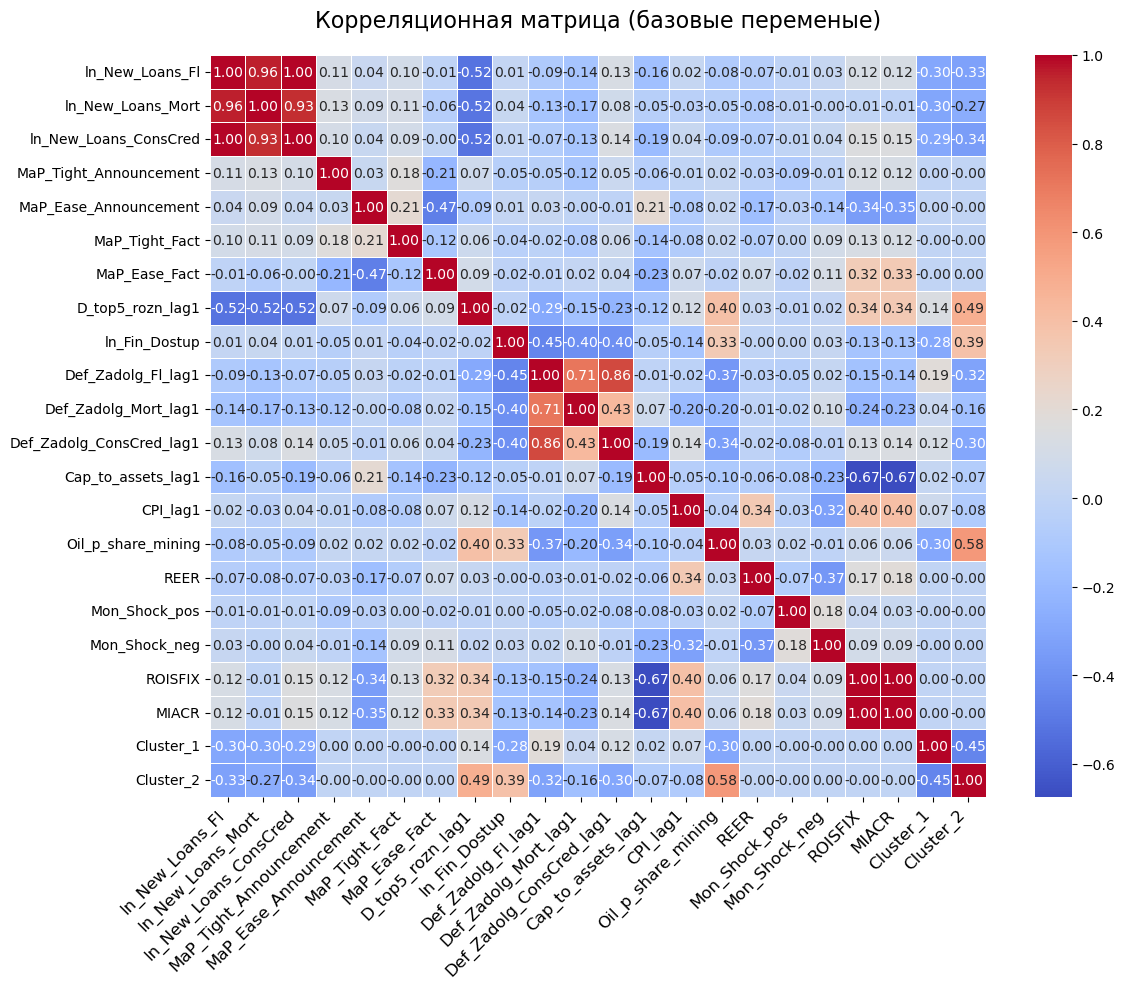

In [20]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - БАЗОВЫЕ ПЕРЕМЕННЫЕ
###############################
descriptive_df = df_exog[[
    #Блок 1 - Зависимые переменные + лаги
    'ln_New_Loans_Fl',
    'ln_New_Loans_Mort',
    'ln_New_Loans_ConsCred',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2'
]]
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (базовые переменые)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

Анализ мультиколлинеарности

In [23]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    #Блок 1 - Лаги зависимых переменных
    'ln_New_Loans_Fl_lag1',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
            Variable      VIF
            Sank_dum 2.770702
           Cluster_2 2.671825
            CPI_lag1 1.942702
ln_New_Loans_Fl_lag1 1.828995
           Cluster_1 1.816988
           Covid_dum 1.746940
  Oil_p_share_mining 1.640929
       ln_Fin_Dostup 1.549366
  Def_Zadolg_Fl_lag1 1.529363
  Cap_to_assets_lag1 1.522274
       Mon_Shock_neg 1.462594
                REER 1.364269
       MaP_Ease_Fact 1.163094
      MaP_Tight_Fact 1.111211
       Mon_Shock_pos 1.067294


In [36]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (Int_Rate_FL зависимая переменная)
###############################


exog_vars_initial = [
    #Блок 1 - Лаги зависимых переменных
    'ln_New_Loans_Fl_lag1',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'ln_New_Loans_Fl'

y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    df_exog, df_exog, dependent_var, exog_vars_initial, cov_type='clustered', cluster_entity=True, df_name='df_exog'
)

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (df_exog)
Зависимая переменная: ln_New_Loans_Fl

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:        ln_New_Loans_Fl   R-squared:                        0.9999
Estimator:                  PooledOLS   R-squared (Between):              1.0000
No. Observations:                6399   R-squared (Within):               0.7641
Date:                Mon, Jan 26 2026   R-squared (Overall):              0.9999
Time:                        12:05:52   Log-likelihood                    2977.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   4.918e+06
Entities:                          81   P-value                           0.0000
Avg Obs:                       79.000   Distribution:                 F(15,6384)
Min Obs:                       79.000                                           
Max

C:\Users\Admin\Test\panel_utils.py:1134: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Cluster_1, Cluster_2

  fe_res = fe_mod.fit(cov_type=cov_type, cluster_entity=cluster_entity)


                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_New_Loans_Fl   R-squared:                        0.7920
Estimator:                   PanelOLS   R-squared (Between):              0.9142
No. Observations:                6399   R-squared (Within):               0.7920
Date:                Mon, Jan 26 2026   R-squared (Overall):              0.9142
Time:                        12:05:53   Log-likelihood                    3442.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1847.1
Entities:                          81   P-value                           0.0000
Avg Obs:                       79.000   Distribution:                 F(13,6305)
Min Obs:                       79.000                                           
Max Obs:                       79.000   F-statistic (robust):             5024.4
                            

In [26]:
run_panel_model_diagnostics(
    y, X, pooled_res, fe_res, re_res,
    pooled_success, fe_success, re_success
)


MODEL DIAGNOSTICS
Target: ln_New_Loans_Fl
p-value threshold: 0.05

Endogeneity (Durbin-Wu-Hausman, control-function)
H0: regressor is exogenous (p < threshold suggests endogeneity).
            variable    t_stat    p_val
  Oil_p_share_mining  4.618231 0.000004
ln_New_Loans_Fl_lag1  4.607214 0.000004
       MaP_Ease_Fact  4.601543 0.000004
           Cluster_1  4.493948 0.000007
           Cluster_2  4.424279 0.000010
  Cap_to_assets_lag1  4.405387 0.000011
  Def_Zadolg_Fl_lag1  4.384386 0.000012
       Mon_Shock_neg  4.372660 0.000012
       ln_Fin_Dostup  4.281098 0.000019
           Covid_dum  4.228296 0.000024
      MaP_Tight_Fact  4.227185 0.000024
            CPI_lag1  4.189375 0.000028
            Sank_dum -4.145504 0.000034
                REER -4.047028 0.000052
       Mon_Shock_pos  3.908488 0.000094

----------------------------------------------------------------------
MODEL: Pooled OLS
----------------------------------------------------------------------

Heteroskedastic

In [27]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====

run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -176.6449
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3118.4529
p-значение: 0.000000
N (регионов): 81, T (периодов): 79

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -78.7057
p-значение: 1.000000
df: (80, 6303)

Вывод: p >= 0.05 - Pooled адекватна


(-176.64488026660206, 1.0, 3118.4528613769944, 0.0, -78.70570544418123, 1.0)

In [23]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    #Блок 1 - Лаги зависимых переменных
    'ln_New_Loans_Fl',
    'ln_New_Loans_Mort',
    'ln_New_Loans_ConsCred',
    'ln_New_Loans_Fl_lag1',
    'ln_New_Loans_Mort_lag1',
    'ln_New_Loans_ConsCred_lag1',
    #Блок 2 - Переменные интереса + лаги
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    'MaP_Tight_Announcement_lag1',
    'MaP_Ease_Announcement_lag1',
    'MaP_Tight_Fact_lag1',
    'MaP_Ease_Fact_lag1',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'Mon_Shock_pos',
    'Mon_Shock_neg',
    'ROISFIX',
    'MIACR',
    'Mon_Shock_pos_lag1',
    'Mon_Shock_neg_lag1',
    'ROISFIX_lag1',
    'MIACR_lag1',
    #Блок 6 - кластеры
    'Cluster_1',
    'Cluster_2',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum',
    #Блок 8 - взаимодействия
    'MaP_Tight_Announcement_D_top5_rozn_lag1',
    'MaP_Tight_Fact_D_top5_rozn_lag1',
    'MaP_Ease_Announcement_D_top5_rozn_lag1',
    'MaP_Ease_Fact_D_top5_rozn_lag1',
    'MaP_Tight_Announcement_Cap_to_assets_lag1',
    'MaP_Tight_Fact_Cap_to_assets_lag1',
    'MaP_Ease_Announcement_Cap_to_assets_lag1',
    'MaP_Ease_Fact_Cap_to_assets_lag1',
    'MaP_Tight_Announcement_Cluster_1',
    'MaP_Tight_Fact_Cluster_1',
    'MaP_Ease_Announcement_Cluster_1',
    'MaP_Ease_Fact_Cluster_1',
    'MaP_Tight_Announcement_Cluster_2',
    'MaP_Tight_Fact_Cluster_2',
    'MaP_Ease_Announcement_Cluster_2',
    'MaP_Ease_Fact_Cluster_2' 
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
                                 Variable         VIF
                          ln_New_Loans_Fl 3811.607597
                     ln_New_Loans_Fl_lag1 3703.387466
                    ln_New_Loans_ConsCred 2287.068294
               ln_New_Loans_ConsCred_lag1 2283.954136
                                    MIACR 1672.248319
                            MaP_Ease_Fact 1589.880190
                    MaP_Ease_Announcement 1465.046697
                                  ROISFIX 1421.945648
                             ROISFIX_lag1 1385.578462
                               MIACR_lag1 1184.334708
                           MaP_Tight_Fact  995.250771
                   MaP_Tight_Announcement  960.079479
 MaP_Ease_Announcement_Cap_to_assets_lag1  736.084410
         MaP_Ease_Fact_Cap_to_assets_lag1  731.314353
           MaP_Ease_Fact_D_top5_rozn_lag1  519.792518
   MaP_Ease_Announcement_D_top5_rozn_lag1  487.084552
        MaP_Ti